In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import random
import simpy
from tqdm import tqdm
import itertools

# $2^k$ Factorial Analysis

We use the example of the airport gate reader simulation to conduct a $2^k$ factorial analysis. In particular, we investigate the effects of (i) the number of servers (i.e., the number of gate readers operating in parallel) and (ii) the service rate of these servers.

The notebook is structured into three steps:

- **Step 1:** Set up the $2^k$ factorial experiment and run the simulations  
- **Step 2:** Extract responses and calculate effect sizes  
- **Step 3:** Interpret the results 

## Step 1: Conduct Simulation Runs

We slightly adapt the DES simulation from the notebooks `09_01_gate_1.ipynb` and `09_01_gate_2.ipynb` in order to perform a $2^k$ factorial analysis. In particular, we define a low and a high value for both the number of servers and the service rate (expressed as $1/\text{service time}$):

| Factor          | Low Value (-) | High Value (+) |
|-----------------|---------------|----------------|
| `SERVERS`       | 2             | 3              |
| `SERVICE_RATE`  | $1/6.0$       | $1/4.8$        |

Next, we run $4{,}000$ simulations (`NUM_RUNS`) for each combination of factor levels over a time horizon of $2 \times 3600$ seconds. Since we consider two factors with two levels each, a total of four scenarios must be simulated.

After completing the simulations, we evaluate the responses. In this example, we use the **average delay experienced by passengers in steady state** as the response variable.

| Response   | `SERVERS` | `SERVICE_RATE` |
|------------|-----------|----------------|
| $R_1$      | low       | low            |
| $R_2$      | low       | high           |
| $R_3$      | high      | low            |
| $R_4$      | high      | high           |

In [ ]:
# Simulation parameters
mean_interarrival_time = 5.1                    # Mean interarrival time (seconds) from Gate Simulation Example
ARRIVAL_RATE = 1/mean_interarrival_time  # Arrival Rate [passengers per unit time] ()
SIM_TIME = 2 * 3600                             # Total simulation time
NUM_RUNS = 4000                                 # Number of independent simulation runs
CUSTOMER_INTERVAL = 5                           # Record delays for every 5th customer

# Factor levels
SERVERS = [2, 3]                     # Factor 1: Number of servers
SERVICE_RATES = [1/6.0, 1/4.8]     # Factor 2: Service rate per server (1/service time)

# Function to generate interarrival times
def generate_interarrival_time(arrival_rate):
    """Generate interarrival time based on exponential distribution."""
    return random.expovariate(arrival_rate)

# Function to generate service times
def generate_service_time(mean_service_rate):
    """Generate service time based on exponential distribution."""
    return random.expovariate(mean_service_rate)

# Simulation function
def simulate_one_run(c, service_rate, customer_interval):
    """Simulate a single M/M/c run with given `c` servers and `service_rate`."""
    delays = {}
    queue_lengths = {}

    def customer(env, name, server, service_rate):
        """A customer process arriving and waiting for service."""
        arrival_time = env.now
        queue_length_at_arrival = len(server.queue)  # Log queue length

        with server.request() as request:
            yield request  # Wait for the server
            wait_time = env.now - arrival_time  # Time spent in queue
            
            if name % customer_interval == 0:  # Record for every `customer_interval` customer
                delays[name] = wait_time
                queue_lengths[name] = queue_length_at_arrival
            
            service_time = generate_service_time(service_rate)
            yield env.timeout(service_time)  # Simulate service

    def arrival_process(env, server, arrival_rate, service_rate):
        """Process generating customers according to a Poisson arrival process."""
        customer_id = 0
        while True:
            interarrival_time = generate_interarrival_time(arrival_rate)
            yield env.timeout(interarrival_time)
            customer_id += 1
            env.process(customer(env, customer_id, server, service_rate))

    # Create the simulation environment
    env = simpy.Environment()
    server = simpy.Resource(env, capacity=c)
    env.process(arrival_process(env, server, ARRIVAL_RATE, service_rate))
    env.run(until=SIM_TIME)

    return delays, queue_lengths

# Dictionary to store results for all (SERVERS × SERVICE_RATES) combinations
results = {}

# Run the simulation for all combinations of SERVERS & SERVICE_RATES
for c, service_rate in itertools.product(SERVERS, SERVICE_RATES):
    key = f"Servers={c}, ServiceRate={service_rate:.4f}"  # Unique key for each setting

    all_delays = {i: [] for i in range(CUSTOMER_INTERVAL, SIM_TIME, CUSTOMER_INTERVAL)}
    all_queue_lengths = {i: [] for i in range(CUSTOMER_INTERVAL, SIM_TIME, CUSTOMER_INTERVAL)}

    # Run simulations with tqdm progress bar
    for _ in tqdm(range(NUM_RUNS), desc=f"Simulating {key}", unit="run"):
        delays, queue_lengths = simulate_one_run(c, service_rate, CUSTOMER_INTERVAL)

        for customer, delay in delays.items():
            if customer in all_delays:
                all_delays[customer].append(delay)

        for customer, queue_length in queue_lengths.items():
            if customer in all_queue_lengths:
                all_queue_lengths[customer].append(queue_length)

    # Store results in dictionary
    results[key] = (
        pd.DataFrame.from_dict(all_delays, orient="index").T,  # Delay DataFrame
        pd.DataFrame.from_dict(all_queue_lengths, orient="index").T  # Queue Length DataFrame
    )

Simulating Servers=3, ServiceRate=0.2083: 100%|██████████| 4000/4000 [00:21<00:00, 189.87run/s]


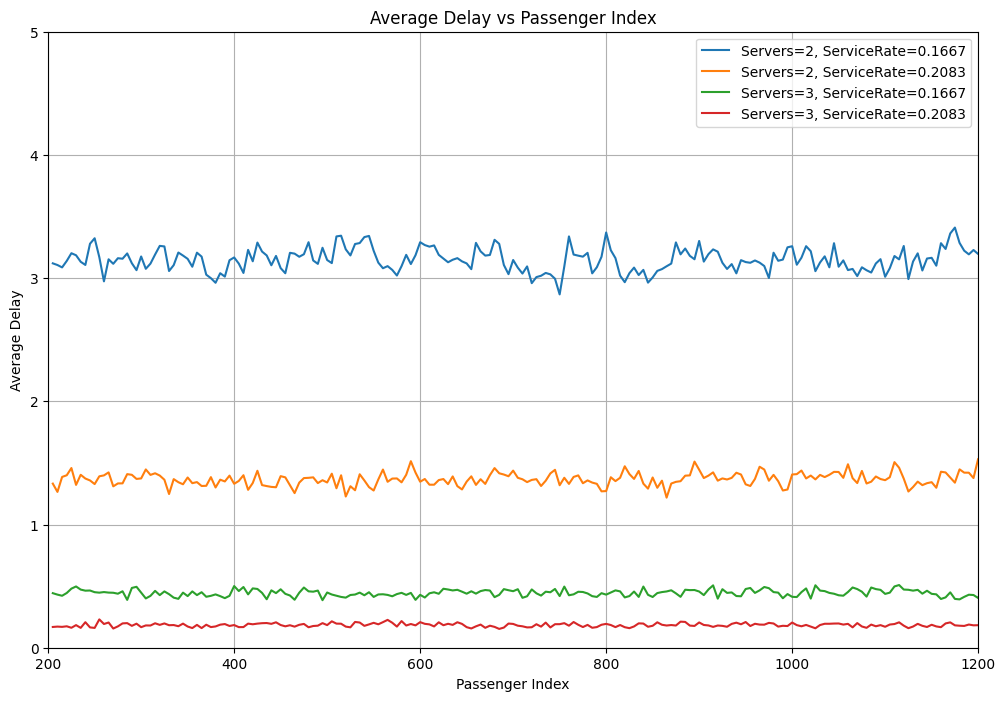

In [ ]:
# Define the index from which to start considering the data for steady-state analysis
idx_steady_start = 200
idx_steady_end = 1200

plt.figure(figsize=(12, 8))

for key, (df_delays, _) in results.items():
 
    num_servers, service_rate=key.split(",")
    num_servers=int(num_servers.split("=")[1])
    service_rate=float(service_rate.split("=")[1])
    df_delays.columns=df_delays.columns.astype(int)
    df_delay_steady=df_delays.loc[:,df_delays.columns>idx_steady_start]
    mean_values = df_delay_steady.mean(axis=0)
   
    mean_delays = df_delay_steady.mean()  # Mittelwert über alle Simulationen
    plt.plot(mean_values.index, mean_values.values, label=key)
 
 
plt.xlabel('Passenger Index')
plt.ylabel('Average Delay')
plt.title('Average Delay vs Passenger Index')
plt.legend()
plt.xlim((idx_steady_start, idx_steady_end))
plt.ylim((0, 5))
plt.grid(True)
plt.show()

## Step 2: Extracting Responses & Calculating Effect Sizes

For each simulation run, we first determine the *responses* $R_1$ to $R_4$. In this example, we define the response as the **average delay experienced by passengers in the steady-state region** of the simulation results. The plot below illustrates the responses for all four simulation scenarios (i.e., all combinations of low/high values of the factors `SERVERS` and `SERVICE_RATE`).

In a second step, we compute the **effect sizes** $e_1$ and $e_2$ using the following equations:

$$
e_1 = \frac{(R_2 - R_1) + (R_4 - R_3)}{2}
$$

$$
e_2 = \frac{(R_3 - R_1) + (R_4 - R_2)}{2}
$$

In [ ]:
average_mean_delays = {}

for key, (df_delays, _) in results.items():
    # Extract values from key
    num_servers, service_rate = key.split(", ")  
    num_servers = int(num_servers.split("=")[1])
    service_rate = float(service_rate.split("=")[1])

    # Convert column names to integers
    df_delays.columns = df_delays.columns.astype(int)

    # Select only columns where idx_steady_start < index < idx_steady_end
    df_delays_steady = df_delays.loc[:, (df_delays.columns > idx_steady_start) & (df_delays.columns < idx_steady_end)]

    # Compute mean delay in steady-state
    mean_delays_steady = df_delays_steady.mean(axis=0).mean()

    # Calculate the average mean delay
    average_mean_delays[(num_servers, service_rate)] = mean_delays_steady


# Display the results
print("Average Mean Delays for Customer Indices Between 750 and 3000:")
for i, (key, avg_delay) in enumerate(average_mean_delays.items()):
    num_servers, service_rate = key
    print(f"Service Rate={service_rate:.4f}, Servers={num_servers}: Average Mean Delay R_{i+1:.0f}= {avg_delay:.4f}")

Average Mean Delays for Customer Indices Between 750 and 3000:
Service Rate=0.1667, Servers=2: Average Mean Delay R_1= 3.1487
Service Rate=0.2083, Servers=2: Average Mean Delay R_2= 1.3669
Service Rate=0.1667, Servers=3: Average Mean Delay R_3= 0.4448
Service Rate=0.2083, Servers=3: Average Mean Delay R_4= 0.1841


In [34]:
# Extract values as a list
R_values = list(average_mean_delays.values())  

# Assign R_1, R_2, R_3, R_4 to the first four values
R_1, R_2, R_3, R_4 = (R_values + [None] * 4)[:4] 

# Calculate Effect Size e_1 and e_2
e_1 = ((R_2 -R_1)+(R_4-R_3))/2
e_2 = ((R_3 -R_1)+(R_4-R_2))/2


# Display the results
print(f"R_1 = {R_1:.4f}")
print(f"R_2 = {R_2:.4f}")
print(f"R_3 = {R_3:.4f}")
print(f"R_4 = {R_4:.4f}")
print(f"Effect Size e_1 = {e_1:.4f}")
print(f"Effect Size e_2 = {e_2:.4f}")    

R_1 = 3.1487
R_2 = 1.3669
R_3 = 0.4448
R_4 = 0.1841
Effect Size e_1 = -1.0213
Effect Size e_2 = -1.9433


## Step 3: Interpretation of Results:

The **responses** $R_1 , R_2, R_3, R_4$ quantify the average delays under steady-state conditions for the different combinations of the two factors:
- $R_1$: Average delay for `num_servers = 2` (low level) and `service_rate = 1/6.0` (low level)  
- $R_2$: Average delay for `num_servers = 2` (low level) and `service_rate = 1/4.8` (high level)  
- $R_3$: Average delay for `num_servers = 3` (high level) and `service_rate = 1/6.0` (low level)  
- $R_4$: Average delay for `num_servers = 3` (high level) and `service_rate = 1/4.8` (high level)  

The **effect sizes** $e_1, e_2$ indicate how much the average delay changes when changing a factor from its low state ($-$) to its high state ($+$):
- The *magnitude* of the effect sizes indicates the strength of the influence of each factor on the average delay. Larger absolute values indicate a stronger influence.
- The *sign* of the effect size indicates the direction of the effect: a negative value means that increasing the factor reduces the average delay, while a positive value means that increasing the factor increases the average delay.  


- **$e_1$ (number of servers):** A negative value indicates that increasing the number of servers reduces the average delay. In this case, increasing the number of servers from 2 to 3 leads to a **substantial reduction in mean delay**, as seen by the large difference between $(R_1, R_2)$ and $(R_3, R_4)$. This is consistent with queueing theory, where adding servers increases system capacity and reduces waiting times.

- **$e_2$ (service rate):** A negative value indicates that increasing the service rate reduces the average delay. In this case, increasing the service rate from $1/6.0$ (slow service) to $1/4.8$ (faster service) leads to a **significant decrease in mean delay**. This is expected, as faster service reduces congestion and waiting times in the system.

Overall, both factors have a strong impact on system performance, with the service rate ($e_2 = -1.9433$) showing a larger absolute effect than the number of servers ($e_1 = -1.0213$), indicating that improvements in service speed have the greatest influence on reducing delays in this system.